In [1]:
import numpy as np
import jax.numpy as jnp
import os
import matplotlib.pyplot as plt
import seaborn as sns
import fsps
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70
rng = np.random.default_rng(13)

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

from project_utils import open_pickled_file, setup_matplotlib_styles

setup_matplotlib_styles()
colors = ['dodgerblue', 'coral', 'darkviolet', 'limegreen', 'mediumvioletred', 'teal']
sns.set_palette(colors)

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 0.02)  # constant metallicity (Z=0.02)
zh = jnp.linspace(0.0002, 0.2, len(tau))

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

path_figs = '/Users/amanda/Desktop/PhD/Tools/ceridwen/figs/presentation'

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

def gaussian_burst(center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

def exp_decay(tau_scale):
    """Exponential decay with lookback time scale tau_scale (Gyr)."""
    return jnp.exp(-tau / tau_scale)

def smooth_random_sfr(k=5):
    """Random positive SFH: draw nonnegative coefficients and combine smooth bases."""
    # Smooth bases = wide Gaussians across 0..T_UNIV
    centers = np.linspace(0.1, T_UNIV*0.95, k)
    widths  = np.linspace(T_UNIV/12, T_UNIV/5, k)
    coeffs  = rng.lognormal(mean=-0.2, sigma=0.7, size=k)  # positive, varied
    s = jnp.zeros_like(tau)
    for c, w, a in zip(centers, widths, coeffs):
        s = s + a * jnp.exp(-0.5 * ((tau - c)/w)**2)
    return s / (jnp.mean(s) + 1e-12)


def bursty_sfr(n_bursts=(12, 20), width_range=(0.01, 0.15), floor_frac=1e-3):
    """
    Very bursty SFH as a sum of many narrow Gaussians in lookback time.
    - n_bursts: number of bursts (uniform integer in the given range)
    - width_range: Gaussian sigma range in Gyr (narrow -> bursty)
    - floor_frac: small constant floor as a fraction of mean burst level to avoid exact zeros
    """
    n = rng.integers(n_bursts[0], n_bursts[1]+1)
    centers = rng.uniform(low=0.0001, high=T_UNIV*0.5, size=n)          # Gyr (avoid exact edges)
    widths  = rng.uniform(low=width_range[0], high=width_range[1], size=n)  # Gyr
    amps    = rng.lognormal(mean=0.0, sigma=1.0, size=n)               # heavy-tail burst strengths

    s = jnp.zeros_like(tau)
    for c, w, a in zip(centers, widths, amps):
        s = s + a * jnp.exp(-0.5 * ((tau - c) / w) ** 2)

    # tiny floor to keep CSP/FSPS stable where interpolation or masking happens
    floor = floor_frac * jnp.mean(s + 1e-12)
    s = s + floor


    # normalize to unit mass over forward time t (or equivalently tau)
    s = s / (jnp.trapezoid(s, t) + 1e-30)
    return s


# 1) Very young (recent) — burst within last 50 Myr
sfr_young = gaussian_burst(center_tau=0.03, width_tau=0.02, amp=1.0)


# 2) Very old — early universe burst ~ 12 Gyr lookback
sfr_old = gaussian_burst(center_tau=12.0, width_tau=1.0, amp=1.0)

# 3) Young + old components (bimodal)
sfr_bimodal = (gaussian_burst(0.05, 0.03, 1.0) +
               gaussian_burst(11.0, 0.8, 0.7))

# 4) Very bursty — many narrow bursts
sfr_bursty = bursty_sfr()

# 5–6) Three random smooth SFHs
sfr_rand1 = smooth_random_sfr(k=6)

In [2]:
csp = CSPBasis(ssp_data, dusty=False)

csp.add_sfh(sfr_bimodal, lookback_time=tau)
csp.add_zh(zh, lookback_time=tau)
spec = csp.get_spectrum()

lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


(0.0, 10000.0)

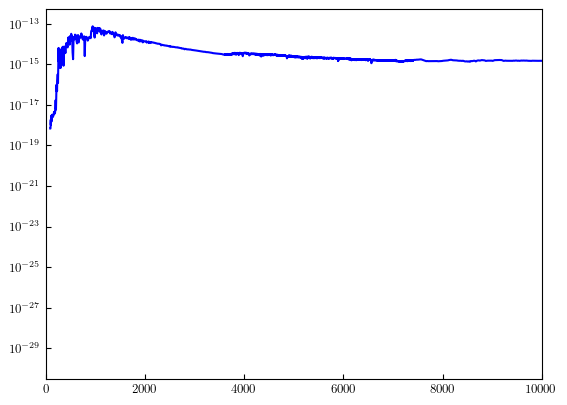

In [3]:
plt.plot(csp.wave, fnu2flam(csp.wave, spec*1e-23*3631), label='FSPS Dust-free', color='blue')
plt.yscale('log')
plt.xlim(0, 10000)

In [4]:

import jax.numpy as jnp
from pathlib import Path
from jax import vmap, jit
#from jax.scipy.interpolate import interp1d
import numpy as np
import astropy.constants as const
import math



from pathlib import Path
import jax.numpy as jnp

class NebularModel:
    def __init__(self, isoc_type, cloudy_dust, sps_home, csp_lambda,
                 mypi, smooth_velocity=True, nebnz=11, nebnage=10, nebnip=7, nebular_smooth_init=100.0):
        """
        Initializes a nebular emission model for use with stellar population synthesis output.

        Parameters
        ----------
        isoc_type : str
            Isochrone type (e.g., 'mist', 'pdva', 'bpss') used to identify the correct nebular files.
        cloudy_dust : bool
            If True, uses nebular models with dust attenuation from CLOUDY.
        sps_home : str or Path
            Path to the FSPS root directory containing the nebular subdirectory.
        csp_lambda : array-like
            Wavelength grid of the composite stellar population (CSP) spectrum [in Angstrom].
.
        mypi : float
            Value of π (can be jnp.pi or float).
        smooth_velocity : bool, optional
            If True, smoothing is velocity-based (km/s). If False, use fixed smoothing in Å.
        nebnz : int, optional
            Number of metallicity grid points.
        nebnage : int, optional
            Number of age grid points.
        nebnip : int, optional
            Number of ionization parameter grid points.
        nebular_smooth_init : float, optional
            Initial smoothing width in km/s or Å (depending on `smooth_velocity`).
        """

        # Store CSP wavelength grid and spectrum length
        self.csp_lambda = jnp.asarray(csp_lambda)
        self.nspec = self.csp_lambda.size

        # Store constants and hyperparameters
        self.mypi = mypi
        self.smooth_velocity = smooth_velocity
        self.nebular_smooth_init = nebular_smooth_init
        self.nebnz = nebnz
        self.nebnage = nebnage
        self.nebnip = nebnip

        # Set filenames for nebular continuum and line emission based on isochrone type and dusty flag
        suffix = 'WD' if cloudy_dust else 'ND'
        base = Path(sps_home) / 'nebular' / f'ZAU_{suffix}_{isoc_type}'
        self.cont_file = base.with_suffix('.cont')   # Nebular continuum file
        self.line_file = base.with_suffix('.lines')  # Nebular emission line file

        # Load the nebular continuum cube and grids
        self._load_continuum()

        # Load the nebular emission line cube and line positions
        self._load_lines()

        # Compute the minimum spectral resolution for each line (in Å)
        self._compute_resolution_elements()

        # Build Gaussian line profiles for all emission lines on the CSP wavelength grid
        self._build_gaussians()

    def __repr__(self):
        def _shape(x):
            try:
                return tuple(jnp.asarray(x).shape)
            except Exception:
                try:
                    return tuple(np.asarray(x).shape)
                except Exception:
                    return "n/a"

        def _minmax(x):
            try:
                xa = jnp.asarray(x)
                return f"{float(jnp.min(xa)):.4g} – {float(jnp.max(xa)):.4g}"
            except Exception:
                return "n/a"

        lines = []
        lines.append("<NebularModel>")
        lines.append("-----------------------------------")
        # Config
        lines.append(f"Files:")
        lines.append(f"  Continuum: {str(self.cont_file)}")
        lines.append(f"  Lines    : {str(self.line_file)}")
        lines.append("")
        lines.append("Grids & settings:")
        lines.append(f"  CSP λ grid shape        : {_shape(self.csp_lambda)}  (nspec={getattr(self, 'nspec', 'n/a')})")
        lines.append(f"  smooth_velocity         : {self.smooth_velocity}")
        lines.append(f"  nebular_smooth_init     : {self.nebular_smooth_init}")
        lines.append(f"  nebnz / nebnage / nebnip: {getattr(self, 'nebnz', 'n/a')} / {getattr(self, 'nebnage', 'n/a')} / {getattr(self, 'nebnip', 'n/a')}")
        lines.append("")
        # Continuum cube + parameter grids
        lines.append("Continuum cube (log10 L/Q):")
        lines.append(f"  nebem_cont shape        : {_shape(getattr(self, 'nebem_cont', None))}  (nspec, nz, nage, nu)")
        lines.append(f"  nebem_logz shape/range  : {_shape(getattr(self, 'nebem_logz', None))} ; {_minmax(getattr(self, 'nebem_logz', None))}")
        lines.append(f"  nebem_age  shape/range  : {_shape(getattr(self, 'nebem_age', None))}  ; {_minmax(getattr(self, 'nebem_age', None))}  (log10 yr)")
        lines.append(f"  nebem_logu shape/range  : {_shape(getattr(self, 'nebem_logu', None))} ; {_minmax(getattr(self, 'nebem_logu', None))}")
        lines.append("")
        # Lines cube
        lines.append("Emission lines (log10 L/Q):")
        lines.append(f"  line positions shape    : {_shape(getattr(self, 'nebem_line_pos', None))}  (Å)")
        lines.append(f"  nebem_line shape        : {_shape(getattr(self, 'nebem_line', None))}  (nlines, nz, nage, nu)")
        lines.append(f"  neb_res_min shape/range : {_shape(getattr(self, 'neb_res_min', None))} ; {_minmax(getattr(self, 'neb_res_min', None))}  (Å)")
        lines.append("")
        # Precomputed Gaussians
        lines.append("Precomputed line profiles:")
        lines.append(f"  gaussnebarr shape       : {_shape(getattr(self, 'gaussnebarr', None))}  (nspec, nlines)")
        lines.append("")
        # Last evaluation (if present)
        lines.append("Last evaluation buffers (optional):")
        lines.append(f"  conflux shape           : {_shape(getattr(self, 'conflux', None))}")
        lines.append(f"  lineflux shape          : {_shape(getattr(self, 'lineflux', None))}")
        lines.append(f"  linespec shape          : {_shape(getattr(self, 'linespec', None))}")

        return "\n".join(lines)

    def _load_continuum(self): 
        # Open the nebular continuum file and skip the header
        with open(self.cont_file, 'r') as f:
            f.readline()  # skip header line

            # Read the wavelength grid of the nebular continuum model
            readlambneb = np.array([float(x) for x in f.readline().split()])
            nlam = len(readlambneb)
            self.readlambneb = jnp.asarray(readlambneb)

            # Read the rest of the file content into memory
            lines = f.readlines()

            # Allocate arrays for interpolated continuum and parameter grids
            cont_cube = np.zeros((self.nspec, self.nebnz, self.nebnage, self.nebnip))
            logz_grid = np.zeros(self.nebnz)   # gas metallicity
            logu_grid = np.zeros(self.nebnip)  # ionization parameter
            age_grid = np.zeros(self.nebnage)  # age in yr

            idx = 0  # line index in the file
            for i in range(self.nebnz):
                for j in range(self.nebnage):
                    for k in range(self.nebnip):
                        # First line gives (logZ, age, logU) for this cube slice
                        parts = [float(x) for x in lines[idx].split()]
                        logz_grid[i], age_grid[j], logu_grid[k] = parts[:3]
                        idx += 1

                        # Second line gives the continuum spectrum (Lsun/Hz/Q)
                        cont = np.array([float(x) for x in lines[idx].split()])
                        logcont = np.log10(cont + 10**-95)  # avoid log(0)
                        # Interpolate onto CSP wavelength grid
                        cont_interp = jnp.interp(self.csp_lambda, readlambneb, logcont)
                        cont_cube[:, i, j, k] = cont_interp
                        idx += 1

        # Store as JAX arrays for GPU compatibility
        self.nebem_cont = jnp.asarray(cont_cube)
        self.nebem_logz = jnp.asarray(logz_grid)
        self.nebem_logu = jnp.asarray(logu_grid)
        self.nebem_age = jnp.log10(jnp.asarray(age_grid))  # log10(age/yr)
    
    def _load_lines(self):
        # Open the nebular emission line file
        with open(self.line_file, 'r') as f:
            f.readline()  # Skip header line

            # Read the rest-frame line center wavelengths (in Å)
            self.nebem_line_pos = jnp.array([float(x) for x in f.readline().split()])
            self.nemline = self.nebem_line_pos.shape[0]

            # Allocate array to store log10(line luminosities) in Lsun/Q
            line_cube = np.zeros((self.nemline, self.nebnz, self.nebnage, self.nebnip))

            # Loop over metallicity, age, and ionization parameter grid
            for i in range(self.nebnz):
                for j in range(self.nebnage):
                    for k in range(self.nebnip):
                        f.readline()  # metadata line (logZ, age, logU), already known
                        linevals = np.array([float(x) for x in f.readline().split()])
                        # Store log10(L/Q), avoiding log(0)
                        line_cube[:, i, j, k] = np.log10(linevals + 10**-95)

            # Store line emission cube as a JAX array for GPU use
            self.nebem_line = jnp.asarray(line_cube)

    
    def _compute_resolution_elements(self):
        '''Avoid delta function spikes in nebular lines when the broadening of the gaussian is smaller than the resolution element.'''
        # For each emission line, find the nearest wavelength index just below the line center
        idx = jnp.clip(
            jnp.searchsorted(self.csp_lambda, self.nebem_line_pos) - 1,
            1, self.nspec - 2 
        )
        
        # Estimate the local spectral resolution element Δλ around each line
        dlam = self.csp_lambda[idx + 1] - self.csp_lambda[idx]

        # Store the minimum resolution per line as a JAX array
        self.neb_res_min = jnp.asarray(dlam)

    
    def _build_gaussians(self):
        """
        Precompute normalized Gaussian line profiles for each emission line,
        on the given wavelength grid. These profiles model the line broadening
        (either in velocity space or wavelength space), and are stored for
        later use when adding line emission to the SED.
        """

        def compute_line(i):
            lam0 = self.nebem_line_pos[i]
            dlam = jnp.where(
                self.smooth_velocity,
                lam0 * self.nebular_smooth_init / (const.c *10**10)* 1e13,  # in Angstrom
                self.nebular_smooth_init
            )
            dlam = jnp.maximum(dlam, self.neb_res_min[i] * 2.0)

            norm = 1.0 / (jnp.sqrt(2 * jnp.pi) * dlam)
            profile = jnp.exp(-0.5 * ((self.csp_lambda - lam0) / dlam) ** 2)
            scaling = lam0 ** 2 / (const.c * 10**10)

            return norm * profile * scaling  # shape: (n_lambda,)

        # Vectorize over all emission lines
        self.gaussnebarr = jnp.stack([compute_line(i) for i in range(self.nebem_line_pos.shape[0])], axis=1)
        return self.gaussnebarr  # shape: (n_lambda, n_lines)

    def evaluate(self, logZ, logU, logage, logQ):

        # Locate and compute fractional offsets in grid
        z1 = locate(logZ, self.nebem_logz)
        dz = jnp.clip((logZ - self.nebem_logz[z1]) / (self.nebem_logz[z1 + 1] - self.nebem_logz[z1]), 0.0, 1.0)

        u1 = locate(logU, self.nebem_logu)
        du = jnp.clip((logU - self.nebem_logu[u1]) / (self.nebem_logu[u1 + 1] - self.nebem_logu[u1]), 0.0, 1.0)

        a1 = locate(logage, self.nebem_age)
        da = jnp.clip((logage - self.nebem_age[a1]) / (self.nebem_age[a1 + 1] - self.nebem_age[a1]), 0.0, 1.0)
        
        # Interpolate log-continuum and line luminosity
        logcont_interp = trilinear_interp(self.nebem_cont, z1, dz, a1, da, u1, du)
        loglines_interp = trilinear_interp(self.nebem_line, z1, dz, a1, da, u1, du)

        # Combine with logQ
        log_cont_flux = logcont_interp + logQ
        log_line_flux = loglines_interp + logQ
        
        # Convert to linear only where absolutely necessary
        cont_flux = 10 ** log_cont_flux  # shape (nspec,)
        line_flux = 10 ** log_line_flux  # shape (nlines,)
        
        # Combine lines
        line_spec = jnp.dot(self.gaussnebarr, line_flux)   # shape (nspec,)
        self.linespec = line_spec  # Store for later use if needed
        self.conflux = cont_flux  # Store for later use if needed
        self.lineflux = line_flux  # Store for later use if needed

        # Final SED
        spec = cont_flux + line_spec  # both in erg/s/cm²/Å

        return spec

def locate(x, grid):
    return jnp.clip(jnp.searchsorted(grid, x) - 1, 0, grid.size - 2)   

def trilinear_interp(cube, z1, dz, a1, da, u1, du):
    """
    Trilinear interpolation on a 4D cube: shape (nspec, nz, nage, nu)
    """
    # Interpolation weights for the 8 surrounding points
    w = jnp.array([
        (1 - dz) * (1 - da) * (1 - du),
        (1 - dz) * (1 - da) * du,
        (1 - dz) * da * (1 - du),
        (1 - dz) * da * du,
        dz * (1 - da) * (1 - du),
        dz * (1 - da) * du,
        dz * da * (1 - du),
        dz * da * du
    ])

    # Stack the 8 corners along a new axis (0), each of shape (nspec,)
    slices = jnp.stack([
        cube[:, z1,   a1,   u1],
        cube[:, z1,   a1,   u1+1],
        cube[:, z1,   a1+1, u1],
        cube[:, z1,   a1+1, u1+1],
        cube[:, z1+1, a1,   u1],
        cube[:, z1+1, a1,   u1+1],
        cube[:, z1+1, a1+1, u1],
        cube[:, z1+1, a1+1, u1+1]
    ], axis=0)  # shape (8, nspec)

    # Weighted sum over the 8 corners
    return jnp.sum(w[:, None] * slices, axis=0)  # shape (nspec,)


In [5]:

import jax.numpy as jnp
from pathlib import Path
from jax import vmap, jit
#from jax.scipy.interpolate import interp1d
import numpy as np
import astropy.constants as const
import math


from ceridwen.neb import NebularModel

In [6]:
ssp_data.ssp_flux.shape
frac_obrun = 0.1  # Example runaway fraction, adjust as needed
log_qq = frac_obrun * ssp_data.log_qq
ssp_data.log_qq[1, 1]

Array(46.541656, dtype=float32)

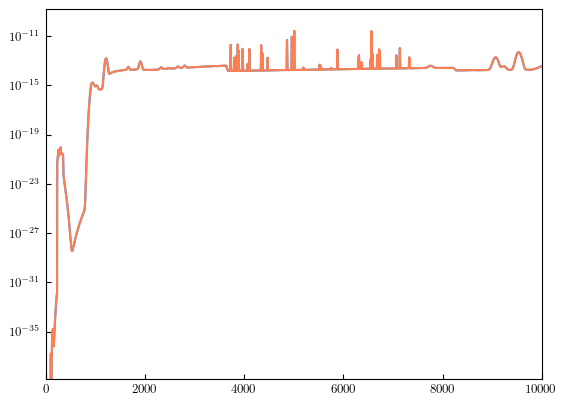

In [7]:

model = NebularModel(
    isoc_type="mist",
    cloudy_dust=True,
    sps_home="/Users/amanda/Prospector/fsps",
    csp_lambda=csp.wave,
    mypi=np.pi,
    nebular_smooth_init=2,
    smooth_velocity=True
)

spec = model.evaluate(
    logZ=-0.82,  # Example metallicity
    logU=-2.0,  # Example ionization parameter
    logage=ssp_data.ssp_lg_age_gyr[1],  # Example age in log years
    logQ=ssp_data.log_qq[1, 1]  # Example ionizing photon rate
)

#plt.plot(model.csp_lambda, model.gaussnebarr, label='Nebular Spectrum', lw=1.5)

#plt.xlim(300, 6100)

plt.plot(csp.wave, spec)
plt.plot(csp.wave, model.conflux + model.linespec)
plt.xlim(0, 10000)
plt.yscale('log')

In [8]:
self = csp

# Ensure logqq has age on axis 0 and metallicity on axis 1
logqq = self.logqq.T

def eval_single(logage, logQ):
    return model.evaluate(logZ=2, logU=3, logage=logage, logQ=logQ)

# Map over ages for one metallicity row
eval_over_age = vmap(eval_single, in_axes=(0, 0))  # (n_age,) x (n_age,) -> (n_age, n_wave)

# Map over metallicities — keep them as the first axis in the output
flux_grid = vmap(lambda logQ_row: eval_over_age(self.ages, logQ_row),
                 in_axes=0, out_axes=0)(self.logqq)

print("ages:", self.ages.shape)
print("logqq:", logqq.shape)              # (n_age, n_metal)
print("flux_grid:", flux_grid.shape)      # (n_age, n_metal, n_wave) typically

ages: (108,)
logqq: (108, 12)
flux_grid: (12, 108, 5994)


In [9]:
csp.flux.shape

(12, 108, 5994)

In [10]:
flux_grid.shape

(12, 108, 5994)

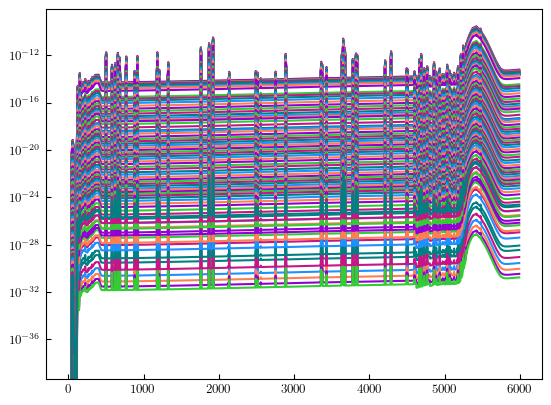

In [11]:
plt.plot(flux_grid[0, :, :].T)
plt.yscale('log')

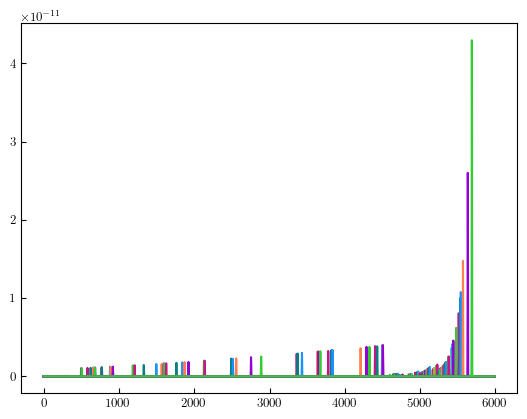

In [15]:
plt.plot(model.gaussnebarr)

TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape float32[5994]
This BatchTracer with object id 6125222976 was created on line:
  /var/folders/vd/kv9mg1cx6tdfwmlfx2m5qfr80000gp/T/ipykernel_5873/319155759.py:7 (eval_single)
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerArrayConversionError

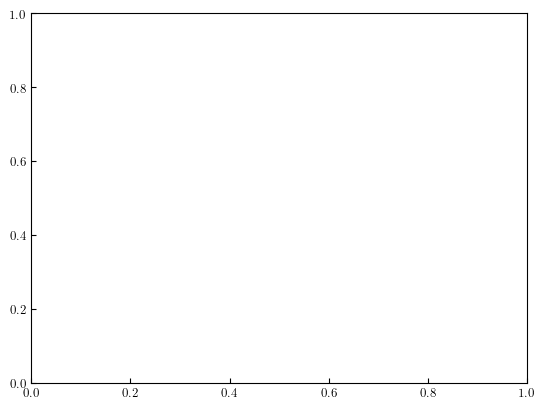

In [16]:
plt.plot(csp.wave, model.linespec)

plt.xlim(0, 10000)
plt.ylim(1e-25, 1e-15)
plt.yscale('log')

UnexpectedTracerError: Encountered an unexpected tracer. A function transformed by JAX had a side effect, allowing for a reference to an intermediate value with type float32[5994] wrapped in a BatchTracer to escape the scope of the transformation.
JAX transformations require that functions explicitly return their outputs, and disallow saving intermediate values to global state.
To catch the leak earlier, try setting the environment variable JAX_CHECK_TRACER_LEAKS or using the `jax.checking_leaks` context manager.
See https://docs.jax.dev/en/latest/errors.html#jax.errors.UnexpectedTracerError

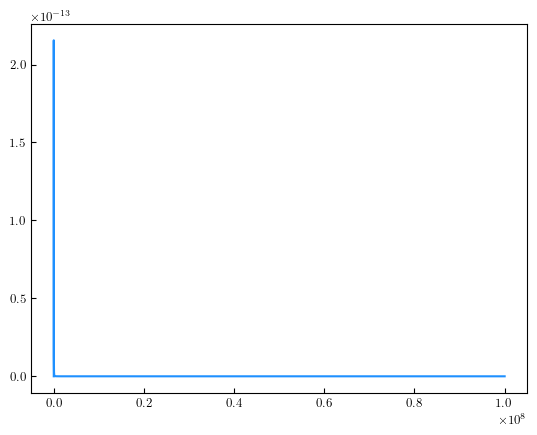

In [17]:
plt.plot(csp.wave, ssp_data.ssp_flux[1, 1, :])
plt.plot(csp.wave, ssp_data.ssp_flux[1, 1, :] + model.conflux, color = 'red')
plt.plot(csp.wave,  ssp_data.ssp_flux[1, 1, :] + spec, color = 'teal')
#plt.plot(csp.wave, model.linespec)

plt.xlim(0, 10000)
plt.ylim(1e-20, 1e-4)
plt.yscale('log')

(0.0, 10000.0)

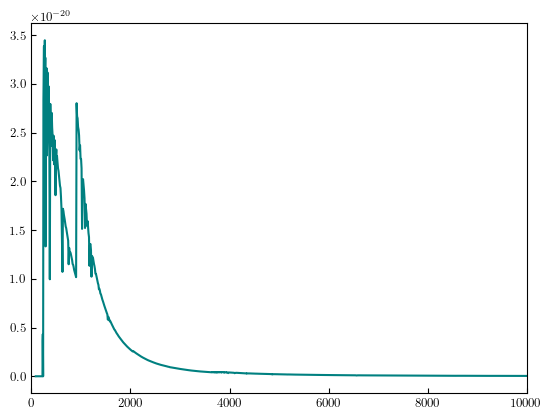

In [18]:
plt.plot(csp.wave,  fnu2flam(csp.wave, (ssp_data.ssp_flux[1, 1, :])*1e-23*3631), color = 'teal')
#plt.plot(csp.wave, model.linespec)

plt.xlim(0, 10000)
#plt.ylim(1e-30, 1e-20)
#plt.yscale('log')

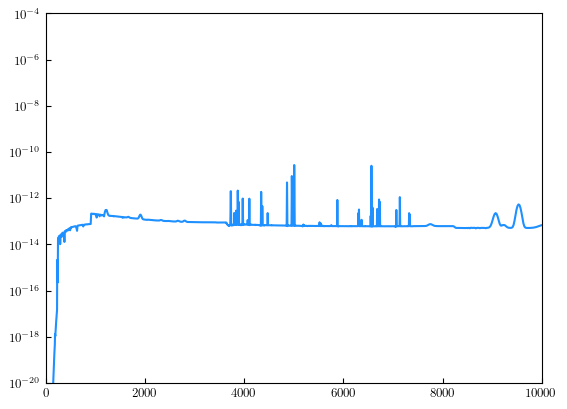

In [19]:

plt.plot(csp.wave, ssp_data.ssp_flux[1, 1, :] + spec)



plt.xlim(0, 10000)
plt.ylim(1e-20, 1e-4)
plt.yscale('log')

In [20]:
nebi = {}

nebi['wave'] = csp.wave[:3000]
nebi['spec'] = jnp.clip(jnp.log10(ssp_data.ssp_flux[1, 1, :])[:3000] +16, 0, None)
nebi['lines'] = jnp.clip(jnp.log10(model.linespec)[:3000] +16, 0, None)
nebi['continuum'] =  jnp.clip(jnp.log10(model.conflux)[:3000] +16, 0, None)

import pickle as pkl
# Save
filename = '/Users/amanda/Desktop/PhD/Tools/ceridwen/animation/data/neb_data.pkl'
with open(filename, 'wb') as f:
    pkl.dump(nebi, f)

with open(filename, 'rb') as f:
    crr = pkl.load(f)

UnexpectedTracerError: Encountered an unexpected tracer. A function transformed by JAX had a side effect, allowing for a reference to an intermediate value with type float32[5994] wrapped in a BatchTracer to escape the scope of the transformation.
JAX transformations require that functions explicitly return their outputs, and disallow saving intermediate values to global state.
To catch the leak earlier, try setting the environment variable JAX_CHECK_TRACER_LEAKS or using the `jax.checking_leaks` context manager.
See https://docs.jax.dev/en/latest/errors.html#jax.errors.UnexpectedTracerError

In [21]:
crr

NameError: name 'crr' is not defined

In [22]:
plt.plot(nebi['wave'], jnp.log10(10**nebi['spec']+ 10**nebi['continuum']))
plt.plot(nebi['wave'], nebi['continuum'])
plt.plot(nebi['wave'], nebi['lines'])


KeyError: 'continuum'